# Mushroom data audit

**Contributors:** initial scaffold and local verification prepared with AI assistance. Team reviewers and substantive changes will be recorded after review. See [the assistance record](../docs/AI_USE.md).

Inspect the teacher's replacement dataset before choosing cleaning and modelling steps. The target labels are `e` (edible) and `p` (poisonous/unsafe). The source is hypothetical. The loader verifies the fingerprint in `SOURCE_DATASET_VERSION.json`.

## Locate the project and load the data

The loader caches the file locally. The audit records its SHA-256 so other group members can check that they used the same bytes.

In [27]:
from pathlib import Path
import sys
ROOT = Path.cwd()
while not (ROOT / 'src' / 'mushrooms.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open this notebook inside the repository folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from mushrooms import load_data, audit, make_split
import pandas as pd
import matplotlib.pyplot as plt
frame = load_data()
report = audit(frame)
print('Shape:', frame.shape)
print('Class counts:', report['class_counts'])
print('Exact duplicates:', report['exact_duplicates'])
print('Feature duplicates:', report['feature_duplicates'])
print('SHA-256:', report['sha256'])
frame.head()

Shape: (5000, 13)
Class counts: {'e': 3107, 'p': 1893}
Exact duplicates: 0
Feature duplicates: 0
SHA-256: 1f1a25f2f330458ed95ce9f6ffe3241582312a42cb21797a2b7bd5e5ad281114


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


## Types and missingness

A missing value is not automatically a zero. Categorical codes are nominal labels. `jumbled_noise_0` and `jumbled_noise_1` are candidates for an ablation study; their names alone are not evidence that removing them helps.

,dtype
cap-diameter,float64
stem-height,float64
stem-width,float64
spore-print-color,str
gill-color,str
habitat,str
season,str
ring-type,str
cap-shape,str
stem-surface,str


,missing_percent
class,0.00
stem-width,7.90
cap-shape,8.12
jumbled_noise_1,8.12
jumbled_noise_0,8.12
ring-type,11.54
season,19.46
gill-color,19.78
habitat,20.08
stem-height,20.26


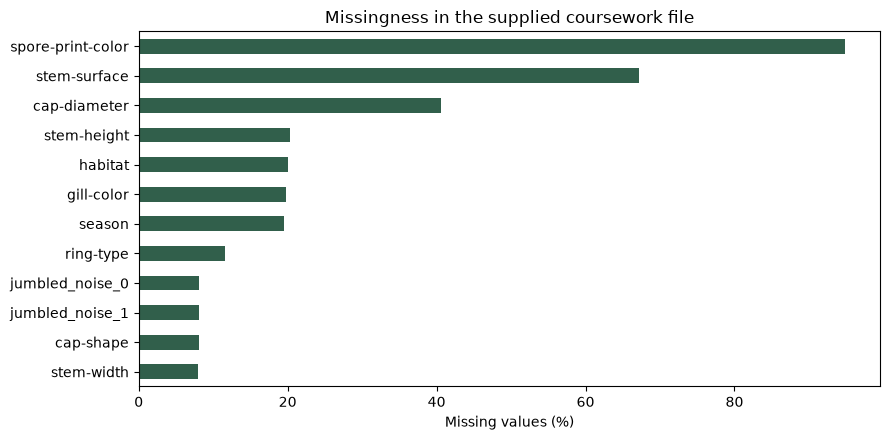

In [28]:
display(frame.dtypes.to_frame('dtype'))
missing = frame.isna().mean().sort_values()*100
display(missing.to_frame('missing_percent'))
fig, ax = plt.subplots(figsize=(9, 4.5))
missing.drop('class').plot.barh(ax=ax, color='#315f4b')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missingness in the supplied coursework file')
fig.tight_layout()
(ROOT/'reports/figures').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT/'reports/figures/missingness.png', dpi=140)
plt.show()

## Reserve the final test data

We use a reproducible stratified 60/20/20 split. Detailed investigation below uses the training subset. The validation subset is for model selection, and the final test subset remains unused in this pilot.

{'train': 3000, 'validation': 1000, 'test': 1000}


,cap-diameter,stem-height,stem-width
count,1819.000000,2377.000000,2770.000000
mean,7.273068,6.693946,12.854361
std,6.372660,3.508978,10.631651
min,0.500000,0.000000,0.000000
25%,3.840000,4.780000,6.030000
50%,6.180000,5.980000,11.255000
75%,8.740000,7.710000,16.977500
max,57.400000,32.430000,102.480000


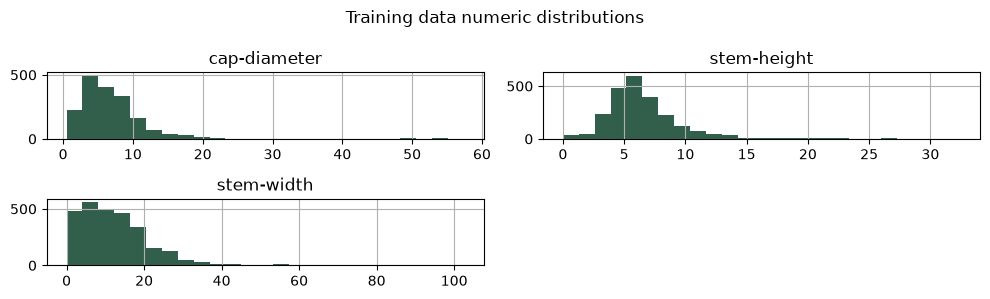

In [29]:
splits = make_split(frame)
training = frame.loc[splits['train']]
print({name: len(indices) for name, indices in splits.items()})
display(training.select_dtypes(include='number').describe())
training.select_dtypes(include='number').hist(figsize=(10, 3), bins=25, color='#315f4b')
plt.suptitle('Training data numeric distributions')
plt.tight_layout()
plt.show()

## Interpretation and next decisions

- `spore-print-color` is about 95% missing. Compare keeping it with a missing category against dropping it, using development folds.
- `stem-surface` is also heavily missing. Investigate whether missingness itself carries a pattern.
- Avoid dropping every incomplete row; quantify how many rows each rule removes and whether class proportions change.
- Compare the two noise columns through a controlled ablation on the same folds.
- Check numeric extremes using training-only plots and document reasons for any treatment.
- The source is hypothetical; species identity is absent. A random split measures performance on similar source rows, not unseen species or real photographs.

The next notebook begins the model comparison. This audit is an initial inspection, not a finished EDA story.

# Task 8 - Mushroom exploration

**Owner:** Viviana Pajic. Some of the implamantation and initial explanations were prepared with AI assistance; see [the assistance record](../docs/AI_USE.md).

The audit above lists open questions. Here we answer them: we look at the class
balance, missing values, numeric and categorical features, outliers and the two
noise columns, and decide which cleaning steps are worth doing. Every decision
at the end is backed by a statistical test or an experiment, not only by a graph.

We use the 4,000 development rows (training and validation). The 1,000 reserved
test rows stay unseen to avoid snoop bias: if test data influenced our cleaning
choices, the final test score would be too optimistic.

In [30]:
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from mushrooms import NOISE_COLUMNS

dev = frame.loc[splits['train'] + splits['validation']].copy()
poison = dev['class'].eq('p')
COLORS = {'e': '#315f4b', 'p': '#b5523b'}
numeric = dev.select_dtypes('number').columns.tolist()
categorical = dev.select_dtypes(exclude='number').columns.drop('class').tolist()
print('Development rows:', len(dev))

Development rows: 4000


## 1. Class balance

If one class is much more common, accuracy becomes misleading: a model that
always says "edible" already scores the share of edible mushrooms.

,count,share
class,,
e,2485,0.621
p,1515,0.379


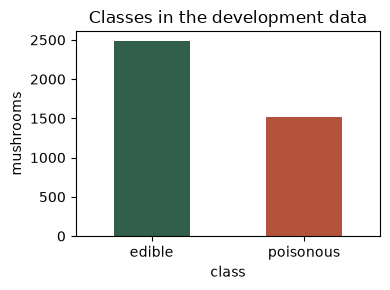

In [31]:
counts = dev['class'].value_counts()
display(pd.DataFrame({'count': counts, 'share': counts.div(len(dev)).round(3)}))
counts.rename({'e': 'edible', 'p': 'poisonous'}).plot.bar(color=[COLORS['e'], COLORS['p']], rot=0, figsize=(4, 3))
plt.title('Classes in the development data'); plt.ylabel('mushrooms'); plt.tight_layout(); plt.show()

About 62% of the mushrooms are edible and 38% poisonous, so the classes are
moderately imbalanced. Always guessing "edible" gives 62% accuracy while
missing every poisonous mushroom, so accuracy will not be our main metric. The
imbalance is not extreme, so we do not resample the data; giving the poisonous
class more weight is an option to try when tuning.

## 2. Missing values: how many, and do they mean something?

For each column we compare the share of poisonous mushrooms when the value is
missing with the share when it is present. If they differ, "missing" itself
carries information. A chi-square test tells whether the difference is bigger
than chance (p < 0.05).

In [32]:
rows = []
for column in dev.columns.drop('class'):
    missing = dev[column].isna()
    _, p_value, _, _ = chi2_contingency(pd.crosstab(missing, poison))
    rows.append({'column': column, 'missing_%': 100 * missing.mean(),
                 'poison_share_if_missing': poison[missing].mean(),
                 'poison_share_if_present': poison[~missing].mean(),
                 'chi2_p_value': p_value})
missing_table = pd.DataFrame(rows).set_index('column').sort_values('missing_%')
display(missing_table.round(3))
print('Rows without any missing value:', int(dev.drop(columns='class').notna().all(axis=1).sum()))

,missing_%,poison_share_if_missing,poison_share_if_present,chi2_p_value
column,,,,
stem-width,8.025,0.389,0.378,0.726
cap-shape,8.050,0.360,0.380,0.513
jumbled_noise_0,8.100,0.420,0.375,0.127
jumbled_noise_1,8.175,0.416,0.375,0.166
ring-type,11.425,0.357,0.382,0.326
gill-color,19.650,0.375,0.380,0.857
season,19.650,0.368,0.381,0.501
habitat,19.825,0.400,0.374,0.187
stem-height,20.275,0.375,0.380,0.829


Rows without any missing value: 6


Only 6 of the 4,000 rows are complete, so deleting incomplete rows is
impossible: we would lose almost all data. We impute instead, with the median
for numbers and a separate `__MISSING__` category for text, learned inside each
training fold so validation rows never influence it.

For most columns the poison share is the same whether the value is missing or
not (p > 0.05), so those gaps look random. The exceptions are
`spore-print-color` and `stem-surface`: when they are recorded, the mushroom is
more often poisonous. Keeping "missing" as its own category preserves that
signal. Section 7 tests whether dropping `spore-print-color` would be better.

## 3. Numeric features: size and outliers

We compare edible and poisonous mushrooms with grouped boxplots and the
Mann-Whitney U test, which checks whether one group tends to have larger values.
We use it instead of a t-test because the sizes are skewed, so a test on means
would be dominated by a few very large mushrooms.

,cap-diameter,stem-height,stem-width
class,,,
edible median,6.60,6.18,12.21
poisonous median,5.38,5.67,8.60


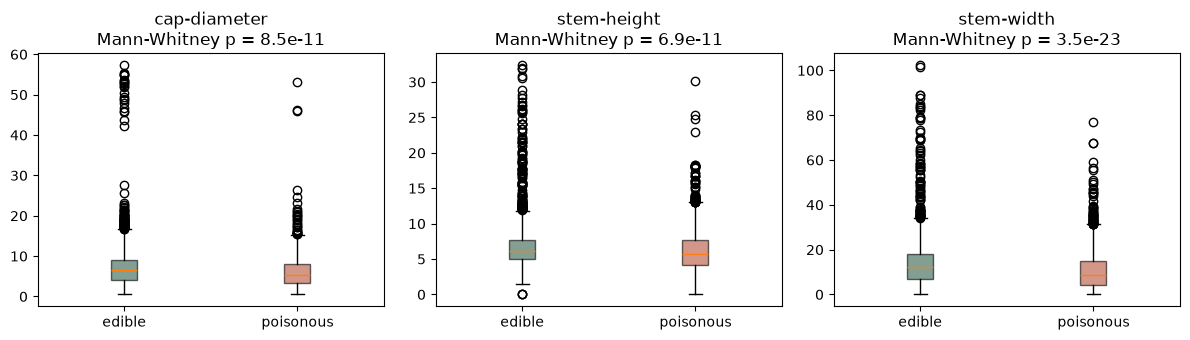

In [33]:
display(dev.groupby('class')[numeric].median().round(2).rename(index={'e': 'edible median', 'p': 'poisonous median'}))
fig, axes = plt.subplots(1, len(numeric), figsize=(12, 3.5))
for ax, column in zip(axes, numeric):
    data = [dev.loc[dev['class'] == c, column].dropna() for c in ['e', 'p']]
    box = ax.boxplot(data, tick_labels=['edible', 'poisonous'], patch_artist=True)
    for patch, color in zip(box['boxes'], COLORS.values()):
        patch.set_facecolor(color); patch.set_alpha(.6)
    ax.set_title(f'{column}\nMann-Whitney p = {mannwhitneyu(*data).pvalue:.1e}')
plt.tight_layout(); plt.show()

Poisonous mushrooms are on average smaller, especially in stem width. All three
differences are significant, but the boxes overlap a lot, so size alone cannot
separate the classes.

To find outliers we use the IQR rule from the course: a value is an outlier when
it lies above Q3 + 1.5 x IQR. We also compare mean and median, because a mean
above the median means a long right tail.

In [34]:
q1, q3 = dev[numeric].quantile(.25), dev[numeric].quantile(.75)
upper = q3 + 1.5 * (q3 - q1)
outlier_table = pd.DataFrame({
    'upper_limit': upper, 'outliers': (dev[numeric] > upper).sum(),
    'outlier_%': 100 * (dev[numeric] > upper).sum() / dev[numeric].notna().sum(),
    'max': dev[numeric].max(), 'mean': dev[numeric].mean(), 'median': dev[numeric].median(),
    'zeros': (dev[numeric] == 0).sum()})
display(outlier_table.round(2))
both_zero = ((dev['stem-height'] == 0) & (dev['stem-width'] == 0)).sum()
print('Rows where stem height AND width are 0:', int(both_zero))
big = dev[dev['cap-diameter'] > 40]
print('Mushrooms with cap > 40 cm:', len(big), '| labels:', big['class'].value_counts().to_dict())

,upper_limit,outliers,outlier_%,max,mean,median,zeros
cap-diameter,16.24,110,4.61,57.40,7.21,6.23,0
stem-height,12.16,183,5.74,32.43,6.70,5.98,40
stem-width,33.83,127,3.45,102.48,12.92,11.34,47


Rows where stem height AND width are 0: 38
Mushrooms with cap > 40 cm: 25 | labels: {'e': 22, 'p': 3}


All three sizes are right-skewed (mean above median), so the IQR rule flags a
few percent of the values. These outliers are genuine observations, not errors:
the largest caps form a small group of mostly edible mushrooms rather than
isolated typos, and the units match the UCI description. We keep them. Tree
models split on thresholds and are not affected by extreme values, and for
logistic regression the numbers are scaled.

Stem height and width are almost always 0 together, which describes mushrooms
without a real stem. So 0 is a real value, not a hidden missing value.

## 4. Do the numeric features measure the same thing?

Strongly correlated features carry the same information, which matters for
linear models. We use Spearman correlation because the sizes are skewed.

,cap-diameter,stem-height,stem-width
cap-diameter,1.00,0.55,0.85
stem-height,0.55,1.00,0.51
stem-width,0.85,0.51,1.00


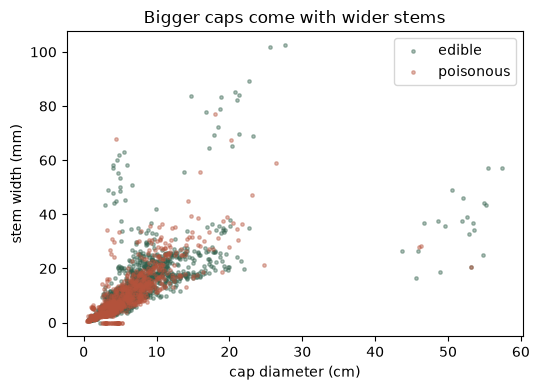

In [35]:
display(dev[numeric].corr(method='spearman').round(2))
fig, ax = plt.subplots(figsize=(5.5, 4))
for label, name in [('e', 'edible'), ('p', 'poisonous')]:
    part = dev[dev['class'] == label]
    ax.scatter(part['cap-diameter'], part['stem-width'], s=6, alpha=.4, color=COLORS[label], label=name)
ax.set_xlabel('cap diameter (cm)'); ax.set_ylabel('stem width (mm)'); ax.legend()
ax.set_title('Bigger caps come with wider stems'); plt.tight_layout(); plt.show()

Cap diameter and stem width are strongly related (about 0.85), stem height only
moderately (about 0.5). We still keep all three. Trees are not bothered by
correlated features, and they are missing in different rows (cap diameter 40%,
stem width 8%), so when the cap diameter is unknown the stem width still carries
most of that size information. The classes overlap everywhere in the scatter
plot: there is no simple size boundary between edible and poisonous.

## 5. Categorical features

All text columns are nominal: their codes have no order. `season` has an order
in time, but it is cyclic, so numbering it 1 to 4 would wrongly make winter the
largest. We therefore use one-hot encoding for all of them.

For each column we run a chi-square test of independence with the class and
compute Cramér's V, the strength of the relation from 0 (none) to 1 (the column
decides the class). The p-value says whether there is a relation; Cramér's V
says how strong it is.

,categories,rare_categories (<20 rows),chi2_p_value,cramers_v
column,,,,
jumbled_noise_0,7,-,0.3693,0.0436
jumbled_noise_1,7,-,0.0537,0.0589
season,4,-,0.0000,0.0813
habitat,8,"p=19, u=10",0.0000,0.1171
gill-color,12,-,0.0000,0.1257
spore-print-color,7,"g=19, u=3, r=2",0.0000,0.1395
ring-type,8,-,0.0000,0.1628
cap-shape,7,-,0.0000,0.1793
stem-surface,8,h=19,0.0000,0.2279


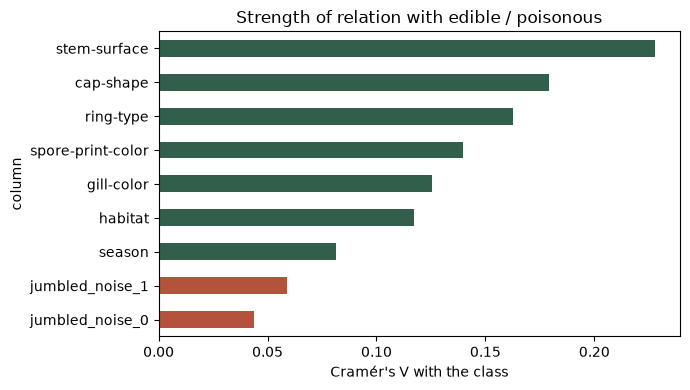

In [36]:
rows = []
for column in categorical:
    table = pd.crosstab(dev[column].fillna('missing'), dev['class'])
    chi2, p_value, _, _ = chi2_contingency(table)
    counts = dev[column].value_counts()
    rows.append({'column': column, 'categories': dev[column].nunique(),
                 'rare_categories (<20 rows)': ', '.join(f'{k}={v}' for k, v in counts[counts < 20].items()) or '-',
                 'chi2_p_value': p_value,
                 'cramers_v': np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))})
association = pd.DataFrame(rows).set_index('column').sort_values('cramers_v')
display(association.round(4))
colors = ['#b5523b' if c in NOISE_COLUMNS else '#315f4b' for c in association.index]
association['cramers_v'].plot.barh(color=colors, figsize=(7, 4))
plt.xlabel("Cramér's V with the class"); plt.title('Strength of relation with edible / poisonous')
plt.tight_layout(); plt.show()

Every real feature has a significant but weak relation with the class (Cramér's
V about 0.1 to 0.2); `stem-surface`, `cap-shape` and `ring-type` are the
strongest. No single column gives the answer, so a good model has to combine
many of them, which explains why tree ensembles beat logistic regression in the
baseline. The two noise columns (red) are the weakest and not significant.

A few categories are rare (fewer than 20 rows, for example `habitat = u`). We do
not merge them: there are only a handful, merging different habitats would mix
unrelated mushrooms, and the encoder ignores unknown codes at prediction time.

## 6. What are the `jumbled_noise` columns?

Their codes look exactly like the `cap-shape` codes. Our hypothesis is that they
are copies of `cap-shape` with the rows shuffled, so they keep the same
distribution but lose the link with the mushroom. We compare the category shares
and how often the values match row by row.

In [37]:
shares = pd.DataFrame({column: dev[column].value_counts(normalize=True)
                       for column in ['cap-shape'] + NOISE_COLUMNS}).round(3)
display(shares)
# After shuffling, two values only match by chance: the sum of (share of each code) squared
expected = (dev['cap-shape'].value_counts(normalize=True) ** 2).sum()
for column in NOISE_COLUMNS:
    both = dev[column].notna() & dev['cap-shape'].notna()
    same = (dev.loc[both, column] == dev.loc[both, 'cap-shape']).mean()
    print(f'{column}: same value as cap-shape in {same:.0%} of rows (pure chance: {expected:.0%})')

,cap-shape,jumbled_noise_0,jumbled_noise_1
b,0.079,0.079,0.074
c,0.032,0.030,0.031
f,0.232,0.235,0.240
o,0.047,0.048,0.047
p,0.046,0.047,0.047
s,0.116,0.118,0.113
x,0.447,0.444,0.448


jumbled_noise_0: same value as cap-shape in 28% of rows (pure chance: 28%)
jumbled_noise_1: same value as cap-shape in 28% of rows (pure chance: 28%)


The category shares are practically identical to `cap-shape`, but row by row the
values match only about as often as pure chance predicts. So these columns are
shuffled `cap-shape` values: realistic-looking, but with no information about
the mushroom. The name alone is not proof that removing them helps, so we test it.

## 7. Do the cleaning ideas actually improve a model?

We train the same two baseline models on five versions of the data, on exactly
the same cross-validation folds (5 folds, repeated twice), and compare ROC-AUC:
the chance that a random poisonous mushroom gets a higher poison probability
than a random edible one (0.5 is guessing, 1 is perfect).

Version 1 uses all columns, version 2 drops the noise columns, version 3 also
drops `spore-print-color`, version 4 replaces `spore-print-color` by a
"recorded" flag, and version 5 is version 2 without the extra "was missing"
columns for the numbers. This cell takes one to two minutes.

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from mushrooms import preprocessor, cv_splitter

X = dev.drop(columns='class')
y = poison.astype(int)
no_noise = X.drop(columns=NOISE_COLUMNS)
spore_flag = no_noise.drop(columns='spore-print-color').assign(
    spore_print_recorded=X['spore-print-color'].notna().astype(int))
versions = {  # name: (data, keep "was missing" columns for numbers?)
    '1. all columns': (X, True),
    '2. drop noise columns': (no_noise, True),
    '3. drop noise + spore-print-color': (no_noise.drop(columns='spore-print-color'), True),
    '4. drop noise, spore-print as flag': (spore_flag, True),
    '5. drop noise, no missing flags': (no_noise, False),
}
models = {
    'logistic regression': lambda: LogisticRegression(max_iter=3000),
    'random forest': lambda: RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                                    random_state=42, n_jobs=-1),
}
rows = []
for version, (data, flags) in versions.items():
    for model_name, make_model in models.items():
        prepare = preprocessor(data, scale=model_name == 'logistic regression', missing_flags=flags)
        scores = cross_validate(Pipeline([('prepare', prepare), ('model', make_model())]),
                                data, y, cv=cv_splitter(), scoring='roc_auc')['test_score']
        rows.append({'data version': version, 'model': model_name,
                     'roc_auc': scores.mean(), 'std': scores.std()})
ablation = pd.DataFrame(rows)
display(ablation.pivot(index='data version', columns='model', values=['roc_auc', 'std']).round(4))

roc_auc                \
model                              logistic regression random forest   
data version                                                           
1. all columns                                  0.6867        0.8205   
2. drop noise columns                           0.6884        0.8313   
3. drop noise + spore-print-color               0.6822        0.8270   
4. drop noise, spore-print as flag              0.6846        0.8294   
5. drop noise, no missing flags                 0.6894        0.8341   

                                                   std                
model                              logistic regression random forest  
data version                                                          
1. all columns                                  0.0163        0.0116  
2. drop noise columns                           0.0137        0.0115  
3. drop noise + spore-print-color               0.0141        0.0112  
4. drop noise, spore-print as flag              0.0142        0.0089  
5. drop noise, no missing flags                 0.0143        0.0107

Dropping the noise columns helps: the random forest gains about 0.01 ROC-AUC, the
biggest change in the table, and logistic regression moves in the same
direction. Random patterns give the forest something to memorise, which hurts on
new data, so we drop them.

Dropping `spore-print-color` is slightly worse than keeping it, and a flag is in
between, so the few recorded values carry signal. We keep it with a missing
category.

The "was missing" columns for the numbers do not help; version 5 is even
slightly better. That matches section 2, where the numeric gaps were random. We
drop these columns; for text the `__MISSING__` category stays.

Differences between versions 2 to 5 are smaller than the fold-to-fold spread
(`std`), so they are a weak preference, not proof. The noise-column result is the
consistent one.

## 8. How separable are the classes at all?

The assignment says some labels may have been flipped. If many labels were
wrong, the model would be very sure about some mushrooms whose label says the
opposite. We use out-of-fold predictions: each mushroom is scored by a forest
that never saw it during training.

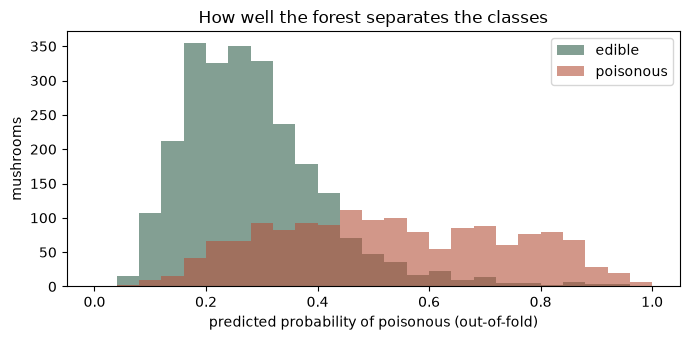

Labelled poisonous but probability < 0.1: 7
Labelled edible but probability > 0.9   : 4


In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
forest = Pipeline([('prepare', preprocessor(no_noise, missing_flags=False)),
                   ('model', RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                                    random_state=42, n_jobs=-1))])
oof = cross_val_predict(forest, no_noise, y, method='predict_proba',
                        cv=StratifiedKFold(5, shuffle=True, random_state=42))[:, 1]
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(0, 1, 26)
for label, name in [(0, 'e'), (1, 'p')]:
    ax.hist(oof[y == label], bins=bins, alpha=.6, color=COLORS[name],
            label='edible' if name == 'e' else 'poisonous')
ax.set_xlabel('predicted probability of poisonous (out-of-fold)'); ax.set_ylabel('mushrooms'); ax.legend()
plt.title('How well the forest separates the classes'); plt.tight_layout(); plt.show()
print('Labelled poisonous but probability < 0.1:', int(((y == 1) & (oof < 0.1)).sum()))
print('Labelled edible but probability > 0.9   :', int(((y == 0) & (oof > 0.9)).sum()))

The two histograms overlap heavily: many poisonous mushrooms get probabilities
between 0.2 and 0.5, the same range as most edible ones. With the default 0.5
cut-off about half of the poisonous mushrooms would be called edible. Only about
ten mushrooms are confident contradictions, so there is no separate group of
obviously flipped labels; the difficulty is spread out over missing values,
removed features and possibly some flipped labels. A near-perfect score like on
the UCI data is not realistic here, and we will have to choose the decision
threshold on purpose (task 11).

## What this completes

Task 8 answers the open questions of the audit with tests and experiments. We
keep all rows and impute missing values inside the model: the median for
numbers and a `__MISSING__` category for text, without extra "was missing"
columns for the numbers. Outliers are genuine and stay, zeros mean "no stem",
and the three sizes are kept although two of them are correlated.

All category codes are nominal and are one-hot encoded; rare categories are kept.
The two `jumbled_noise` columns are shuffled `cap-shape` values and are dropped.
`spore-print-color` stays with a missing category because its few recorded
values carry signal. Column names keep their UCI spelling for now; consistent
names are chosen in the final preparation.

The classes overlap a lot, so the decision threshold is chosen on purpose in
task 11, and notebook 01 applies these decisions (task 13).